In [ ]:
#set the environment variable for Groq API key
import os

if "GROQ_API_KEY" not in os.environ:
    print("Warning: GROQ_API_KEY environment variable not set")


In [ ]:
#Now llm setup
from langchain_groq import ChatGroq

llm = ChatGroq(model="llama-3.1-8b-instant", temperature=0.5)


Define a Graph

-Define a llm schema for the topic categorize

In [ ]:
from pydantic import BaseModel,Field
from typing import Literal
class llm_schema(BaseModel):
    category: Literal["insta","facebook","twitter"] = Field(description="categorize the user input")
    topic : str = Field(description= "about the topic")


In [ ]:
llm_with_schema = llm.with_structured_output(llm_schema)
llm_with_schema.invoke("I want to generate the post for instagram about ai") #if we invoke the linkedin in our query then error occurs due to the literal list we used above

llm_schema(category='insta', topic='ai')

Define state graph

In [ ]:
from typing import TypedDict
class Graph_Schema(TypedDict):
    input : str
    topic: str
    category: str
    post: str


Create a NodeGraph

In [ ]:
def create_insta_post(state:Graph_Schema)-> Graph_Schema:
    topic = state["topic"]
    post = llm.invoke(f"create a insta post about the topic:{topic}").content
    state["post"] = post
    return {
        "post" : post
    }

def create_facebook_post(state:Graph_Schema) -> Graph_Schema:
    topic = state["topic"]
    post = llm.invoke(f"create a post about the topic:{topic}").content
    state["post"] = post
    return {
        "post":post
    }

def create_twitter_post(state:Graph_Schema) -> Graph_Schema:
    topic = state["topic"]
    post = llm.invoke(f"create a post about the topic:{topic}").content
    state["post"] = post
    return {
        "post":post
    }

def decider_node(state:Graph_Schema) -> Graph_Schema:
    #user input herera category decide garxa and state update garxa
    input = state["input"]
    response = llm_with_schema.invoke(input) #object preparation and store in category 
    category = response.category
    topic = response.topic

    #update state
    state["category"] = category
    state["topic"] = topic
    return state
    
    

In [ ]:
def condition_edge(state:Graph_Schema) -> str:
    category = state["category"]

    if category == "insta":
        return "create_insta_post"

    elif category == "facebook":
        return "create_facebook_post"
    
    elif category == "twitter":
        return "create_twitter_post"

    else:
        return "Invalid Category"

CREATE THE STATE GRAPH

In [ ]:
from langgraph.graph import StateGraph,START,END
graph = StateGraph(Graph_Schema)

#add node
graph.add_node("create_insta_post",create_inta_post)
graph.add_node("create_facebook_post",create_facebook_post)
graph.add_node("create_twitter_post",create_twitter_post)
graph.add_node("decider_node",decider_node)

#add edges
graph.add_edge(START,"decider_node")
graph.add_conditional_edges("decider_node",condition_edge,{"create_insta_post": "create_insta_post",
                                                          "create_facebook_post":"create_facebook_post",
                                                          "create_twitter_post": "create_twitter_post"  
                                                            })

graph.add_edge("create_insta_post",END)
graph.add_edge("create_facebook_post",END)
graph.add_edge("create_twitter_post",END)



COMPILE THE GRAPH

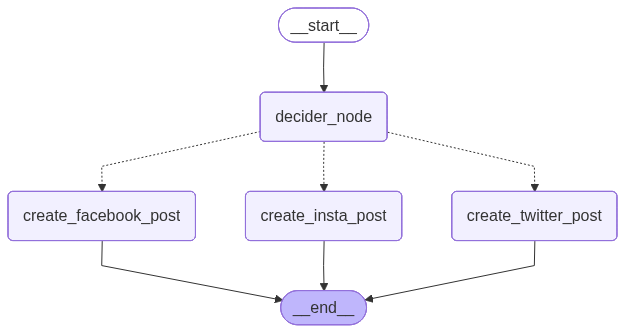

In [ ]:
from IPython.display import Image,display

router_graph = graph.compile()
Image(router_graph.get_graph().draw_mermaid_png())

RUN THE GRAPH

In [ ]:
router_graph.invoke({"input": "write the post about My future dream in facebook",
                    "topic": "",
                    "category": "",
                    "post": ""
})

{'input': 'write the post about My future dream in facebook',
 'topic': 'My future dream',
 'category': 'facebook',
 'post': "**My Future Dream: A Life of Purpose and Fulfillment**\n\nAs I sit here, reflecting on my life's journey so far, I am filled with excitement and anticipation about the future. I have always been driven by a sense of curiosity and a desire to make a positive impact on the world around me. In this post, I want to share with you my future dream - a vision of what I hope to achieve in the years to come.\n\n**My Passion: Environmental Sustainability**\n\nMy future dream is centered around environmental sustainability. I have always been passionate about protecting our planet and preserving its natural resources for future generations. I believe that every small action we take can make a significant difference in reducing our carbon footprint and promoting eco-friendly practices.\n\n**My Goals:**\n\n1. **Start a Sustainable Living Community**: I dream of creating a co